In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better plots in notebooks
%matplotlib inline

# Global style
sns.set_theme(style="whitegrid")

In [2]:
def load_and_prepare_data():
    """
    Load labeled and canonical datasets and merge sector information
    """
    labeled_df = pd.read_csv("labeled_financials.csv")
    canonical_df = pd.read_csv("canonical_financials.csv")
    
    merged_df = labeled_df.merge(
        canonical_df[['company_id', 'financial_year_end', 'sector']].drop_duplicates(),
        on=['company_id', 'financial_year_end'],
        how='left'
    )
    
    return merged_df


# Load data
df = load_and_prepare_data()

print(f"Total labeled rows: {len(df)}")
print(f"Healthy (0): {(df['label'] == 0).sum()}")
print(f"Risky (1): {(df['label'] == 1).sum()}")

df.head(100)


Total labeled rows: 815
Healthy (0): 644
Risky (1): 171


,company_id,financial_year_end,ocf_positive_count,ocf_volatility,financing_dependency_flag,label,operating_cf,investing_cf,financing_cf,total_assets,revenue,sector
0,ABB,2018,2,1144.220404,1,0,2198.0,-3192.0,1589.0,2416.0,3298.0,Capital Goods
1,ABB,2019,3,375.016000,1,0,2591.0,-3050.0,38.0,2941.0,3679.0,Capital Goods
2,ABB,2020,3,229.540846,1,0,5437.0,-5643.0,1250.0,3547.0,4093.0,Capital Goods
3,ABB,2021,3,1767.544719,1,0,3784.0,-4009.0,-745.0,3840.0,4310.0,Capital Goods
4,ABB,2022,3,1429.182400,1,0,4097.0,-3936.0,-235.0,4224.0,4913.0,Capital Goods
...,...,...,...,...,...,...,...,...,...,...,...,...
95,BAJAJFINSV,2020,0,8083.962477,1,1,-23369.0,-9948.0,34479.0,251304.0,54351.0,Financial Services
96,BAJAJFINSV,2021,0,3748.074750,1,1,4547.0,-3684.0,1687.0,279845.0,60592.0,Financial Services
97,BAJAJFINSV,2022,1,17287.081082,1,1,-33670.0,1445.0,32326.0,333413.0,68406.0,Financial Services
98,BAJAJFINSV,2023,1,19773.520787,1,1,-39480.0,-13945.0,51016.0,405401.0,82072.0,Financial Services


In [4]:
def analyze_risky_label_composition(df):
    """
    Analyze what drives risky labels
    """
    risky_df = df[df['label'] == 1]
    healthy_df = df[df['label'] == 0]
    
    results = {}
    
    # % of risky rows with weak OCF history
    results['pct_risky_negative_ocf'] = (
        (risky_df['ocf_positive_count'] < 1.5).mean() * 100
    )
    
    # Avg OCF volatility
    results['avg_volatility_healthy'] = healthy_df['ocf_volatility'].mean()
    results['avg_volatility_risky'] = risky_df['ocf_volatility'].mean()
    
    # Financing dependency
    results['pct_financing_dep_healthy'] = (
        healthy_df['financing_dependency_flag'].mean() * 100
    )
    results['pct_financing_dep_risky'] = (
        risky_df['financing_dependency_flag'].mean() * 100
    )
    
    return results, risky_df, healthy_df


results, risky_df, healthy_df = analyze_risky_label_composition(df)

results


{'pct_risky_negative_ocf': 67.83625730994152,
 'avg_volatility_healthy': 3568.826573315948,
 'avg_volatility_risky': 12669.968283573522,
 'pct_financing_dep_healthy': 20.96273291925466,
 'pct_financing_dep_risky': 85.96491228070175}

In [5]:
def analyze_sector_risk(df):
    """
    Sector-wise risk analysis
    """
    sector_stats = (
        df.groupby('sector')
        .agg(
            total_companies=('label', 'count'),
            risk_rate=('label', 'mean'),
            avg_ocf_volatility=('ocf_volatility', 'mean'),
            avg_financing_dependency=('financing_dependency_flag', 'mean')
        )
        .round(3)
        .sort_values('risk_rate', ascending=False)
    )
    
    return sector_stats


sector_stats = analyze_sector_risk(df)
sector_stats.head(10)


,total_companies,risk_rate,avg_ocf_volatility,avg_financing_dependency
sector,,,,
Financial Services,189,0.566,15200.337,0.688
Retail,30,0.433,185.828,0.767
Transportation / Logistics,23,0.304,5203.027,0.522
Consumer Durables,18,0.222,1016.221,0.000
Diversified / Others,36,0.222,8099.914,0.472
Capital Goods,58,0.207,1290.099,0.155
Construction Real Estate,16,0.125,1143.454,0.250
Construction Materials,33,0.121,2502.582,0.182
Power,57,0.088,1901.329,0.351


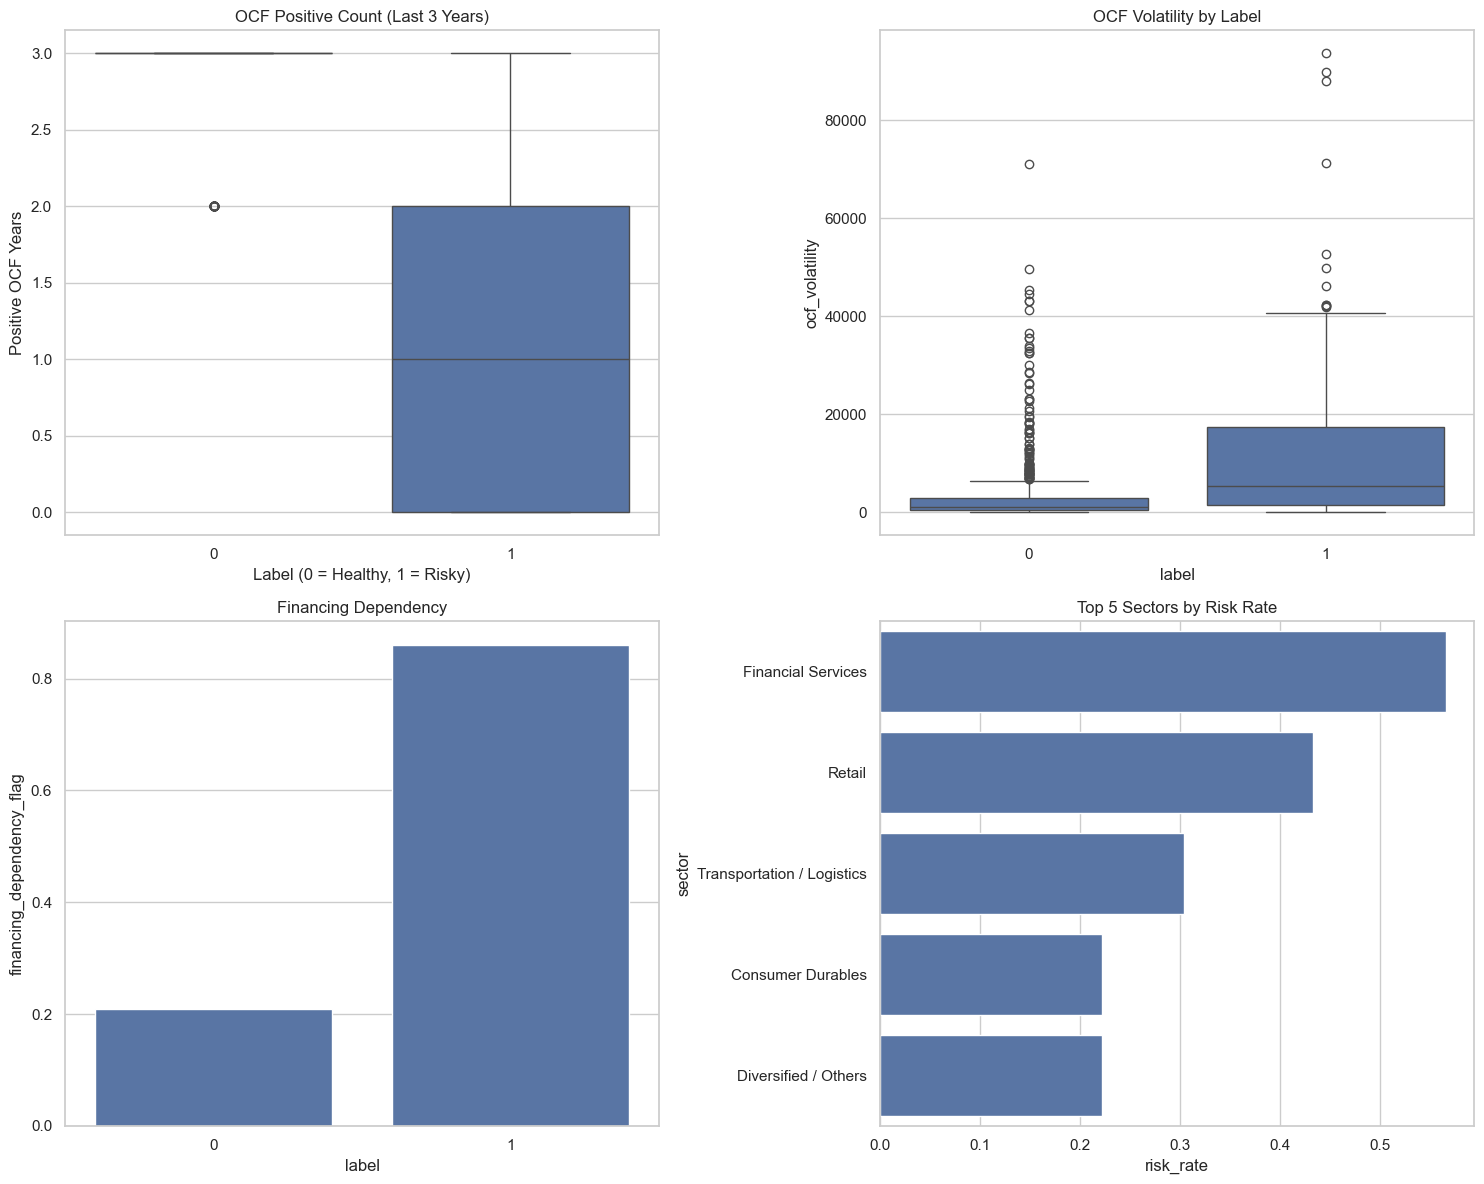

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. OCF Positive Count
sns.boxplot(data=df, x='label', y='ocf_positive_count', ax=axes[0, 0])
axes[0, 0].set_title('OCF Positive Count (Last 3 Years)')
axes[0, 0].set_xlabel('Label (0 = Healthy, 1 = Risky)')
axes[0, 0].set_ylabel('Positive OCF Years')

# 2. OCF Volatility
sns.boxplot(data=df, x='label', y='ocf_volatility', ax=axes[0, 1])
axes[0, 1].set_title('OCF Volatility by Label')

# 3. Financing Dependency
financing_data = (
    df.groupby('label')['financing_dependency_flag']
    .mean()
    .reset_index()
)
sns.barplot(
    data=financing_data,
    x='label',
    y='financing_dependency_flag',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Financing Dependency')

# 4. Top 5 Risky Sectors
top_5_risky = sector_stats.head(5).reset_index()
sns.barplot(
    data=top_5_risky,
    x='risk_rate',
    y='sector',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Top 5 Sectors by Risk Rate')

plt.tight_layout()
plt.show()
